The necessary imports to ensure the code can run properly
torch for deep learning
numpy for calculations
accurcay score ,confusion matrix for metrics
sns for confusion matrix 
matplotlib for graphs
requests,zipfile,io for zipfile

Ensure all dependencies are installed
pip install torch
pip install numpy scikit-learn seaborn matplotlib requests

In [1]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import requests,zipfile,io

This the dataset preprocessing where the vowel dataset is taken it is a sequence of features this data is broken down to enusre that it correctly belongs to the class.

In [2]:
def dataset_preprocessing(path,train=True):
    seq,label,b1=[],[],[]
    d1=[30]*9 if train else [31,35,88,44,29,24,40,50,29]
    c=np.cumsum(d1)
    i=0

    for l in path:
        l=l.strip()
        if l=="":
            if b1:
                seq.append(np.array(b1))
                label.append(np.searchsorted(c,i))
                b1=[]
                i+=1
        else:
            b1.append(list(map(float,l.split())))
    if b1:
        seq.append(np.array(b1))
        label.append(np.searchsorted(c,i))
    return seq,np.array(label)

to convert into tensor and pad the sequence.

In [3]:
def tensor(x,y):
    s=[torch.tensor(x1,dtype=torch.float32) for x1 in x]
    pad=nn.utils.rnn.pad_sequence(s,batch_first=True)
    label=torch.tensor(y)

    return pad,label

Load the dataset from UCI

In [4]:
z=zipfile.ZipFile(io.BytesIO(requests.get("https://archive.ics.uci.edu/static/public/128/japanese+vowels.zip").content))
ae_train=z.read("ae.train").decode().splitlines()
ae_test=z.read("ae.test").decode().splitlines()

preprocess the dataset and store as test and training data.

In [5]:
Xtrain,ytrain=dataset_preprocessing(ae_train,True)
Xtest,ytest=dataset_preprocessing(ae_test,False)

Xtrain,ytrain=tensor(Xtrain,ytrain)
Xtest,ytest=tensor(Xtest,ytest)

The BILSTM model which has 64 hidden layers which help compute the dependencies between the past and future even better.

Accuracy: 0.8757


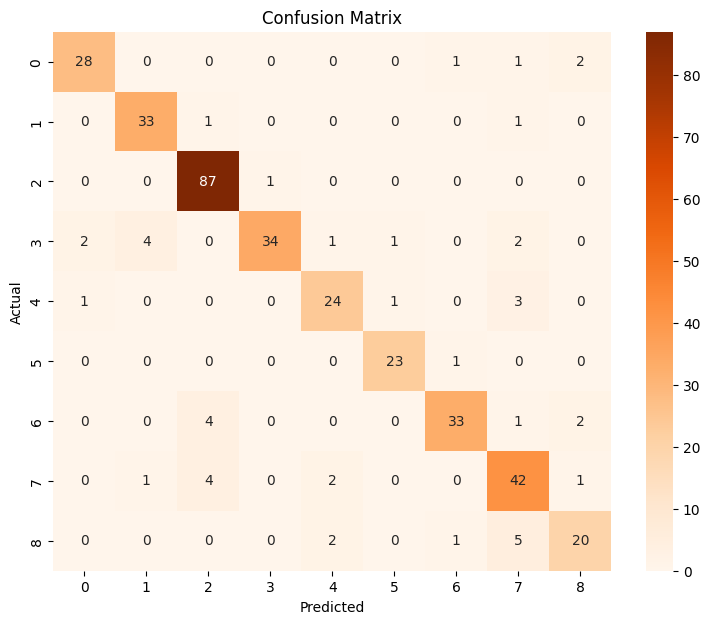

In [6]:
class BiLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm=nn.LSTM(12,64,batch_first=True,bidirectional=True)
        self.fc= nn.Linear(128,9)
    def forward(self,x,):
        a,(h,c)=self.lstm(x)
        return self.fc(torch.cat([h[0],h[1]],dim=1))

model=BiLSTM()
opti=torch.optim.Adam(model.parameters(),lr=1e-3)
criterion=nn.CrossEntropyLoss()

for i in range(200):
    model.train()
    loss=criterion(model(Xtrain),ytrain)
    opti.zero_grad(); loss.backward(); opti.step()

model.eval()
with torch.no_grad():
    preds=model(Xtest).argmax(dim=1).numpy()

print(f"Accuracy: {accuracy_score(ytest,preds):.4f}")
conf=confusion_matrix(ytest,preds)

plt.figure(figsize=(9,7))
sns.heatmap(conf,annot=True,fmt="d",cmap="Oranges")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
